In [1]:
from sentence_transformers import util
from sklearn.metrics.pairwise import cosine_distances
import numpy as np
import json
import pandas as pd
import matplotlib.pyplot as plt
import copy


In [2]:
# Constants
PROMOTE_THRESHOLD = 0.2   # very similar → promote directly
REVIEW_THRESHOLD = 0.25   # borderline → manual review

In [3]:
# Load the data
cq_path = "competency_questions_output/clustered_CQs_with_embeddings.json"
with open(cq_path, "r", encoding="utf-8") as f:
    data = json.load(f)
noise_cl = data["Cluster -1"]

num_cq = sum(len(v) for v in data.values())
num_noise = len(noise_cl)
print(f"There are {num_cq} CQs, of them {num_noise} are noise. Thats {num_noise/num_cq:.2%} of all CQs.")

# Extract embeddings
noise_embeddings = []
for cq in noise_cl:
    noise_embeddings.append(cq["embedding"])

core_embeddings = []
for cluster_name, cqs in data.items():
    if cluster_name == "Cluster -1":
        continue
    for cq in cqs:
        core_embeddings.append(cq["embedding"])

noise_embeddings = np.array(noise_embeddings)
core_embeddings = np.array(core_embeddings)

# Map core index to cluster name
core_index_to_cluster = {}
current_index = 0
for cluster_name, cqs in data.items():
    if cluster_name == "Cluster -1":
        continue
    for _ in cqs:
        core_index_to_cluster[current_index] = cluster_name
        current_index += 1


There are 1709 CQs, of them 332 are noise. Thats 19.43% of all CQs.


Compute d_min for each noise CQ
This tells us how close each noise CQ is to any clustered CQ.

In [4]:
dist_matrix = cosine_distances(noise_embeddings, core_embeddings)

# Get the minimum distance and index of closest core for each noise CQ
d_min = dist_matrix.min(axis=1)
nearest_core_index = dist_matrix.argmin(axis=1)

triaged = {"promote": [], "review": [], "leave": []}

for i, cq in enumerate(noise_cl):
    distance = d_min[i]
    nearest_idx = nearest_core_index[i]
    nearest_cluster = core_index_to_cluster[nearest_idx]

    if distance <= PROMOTE_THRESHOLD:
        triaged["promote"].append({
            "cq": cq["cq"],
            "embedding": cq["embedding"],
            "d_min": float(distance),
            "nearest_core_index": int(nearest_idx),
            "nearest_cluster": nearest_cluster
        })
    elif distance <= REVIEW_THRESHOLD:
        triaged["review"].append({
            "cq": cq["cq"],
            "embedding": cq["embedding"],
            "d_min": float(distance),
            "nearest_core_index": int(nearest_idx),
            "nearest_cluster": nearest_cluster
        })
    else:
        triaged["leave"].append({
            "cq": cq["cq"],
            "embedding": cq["embedding"],
            "d_min": float(distance),
            "nearest_core_index": int(nearest_idx),
            "nearest_cluster": nearest_cluster
        })


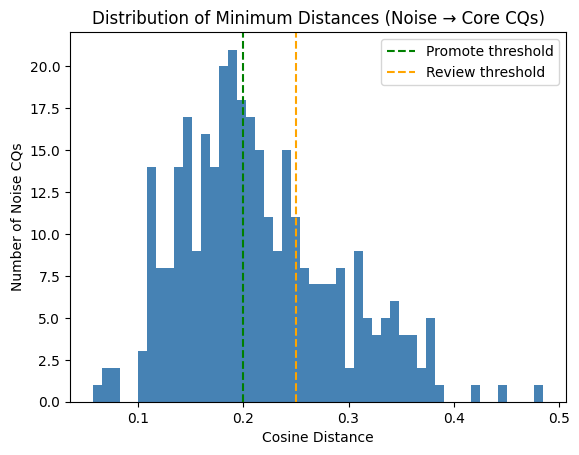

In [5]:
# Plot triaged data
plt.hist(d_min, bins=50, color="steelblue")
plt.title("Distribution of Minimum Distances (Noise → Core CQs)")
plt.xlabel("Cosine Distance")
plt.ylabel("Number of Noise CQs")
plt.axvline(PROMOTE_THRESHOLD, color='green', linestyle='--', label='Promote threshold')
plt.axvline(REVIEW_THRESHOLD, color='orange', linestyle='--', label='Review threshold')
plt.legend()
plt.show()

In [6]:
# Save the triaged data
with open("competency_questions_output/noise_triage.json", "w", encoding="utf-8") as f:
    json.dump(triaged, f, ensure_ascii=False, indent=2)


In [7]:
# Step 1: Copy all clusters except "Cluster -1"
updated_data = {k: copy.deepcopy(v) for k, v in data.items() if k != "Cluster -1"}

# Step 2: Add promoted and review noise CQs to their nearest clusters
for tag in ["promote", "review"]:
    for item in triaged[tag]:
        cluster_name = item["nearest_cluster"]
        cq_entry = {
            "cq": item["cq"],
            "embedding": item["embedding"],
            "from_noise": tag,
            "d_min": item["d_min"]
        }
        updated_data[cluster_name].append(cq_entry)

# Step 3: Create new "Cluster -1" with only the "leave" items
updated_data["Cluster -1"] = [
    {
        "cq": item["cq"],
        "embedding": item["embedding"],
        "from_noise": "leave",
        "d_min": item["d_min"]
    }
    for item in triaged["leave"]
]

ordered_data = dict(sorted(
    updated_data.items(),
    key=lambda x: (x[0] != "Cluster -1", int(x[0].split()[-1]) if x[0].startswith("Cluster ") and x[0] != "Cluster -1" else float('inf'))
))

# Step 4: Save the updated clusters
with open("competency_questions_output/clustered_CQs_with_promoted_and_reviewed_noise.json", "w", encoding="utf-8") as f:
    json.dump(ordered_data, f, ensure_ascii=False, indent=2)


🔎 Top TF-IDF Keywords und Wortfrequenz pro Cluster:

📁 Cluster 0 (n=8):
Top TF-IDF Keywords:
  - netz: TF-IDF=0.305
  - kabelnetzbetreiber: TF-IDF=0.264
  - betreibers: TF-IDF=0.178
  - anderen: TF-IDF=0.159
  - signaldurchleitung: TF-IDF=0.148
  - signale: TF-IDF=0.147
  - kabelnetzes: TF-IDF=0.106
Top Wörter nach Häufigkeit:
  - netz: 7 mal
  - kabelnetzbetreiber: 6 mal
  - welche: 4 mal
  - anderen: 4 mal
  - betreibers: 4 mal
  - signaldurchleitung: 3 mal
  - signale: 3 mal

📁 Cluster 1 (n=9):
Top TF-IDF Keywords:
  - patentnichtigkeitsverfahren: TF-IDF=0.238
  - kläger: TF-IDF=0.195
  - patentnichtigkeitsklage: TF-IDF=0.143
  - patent: TF-IDF=0.124
  - rechtsschutzmöglichkeit: TF-IDF=0.107
  - angegriffene: TF-IDF=0.086
  - argumentieren: TF-IDF=0.086
Top Wörter nach Häufigkeit:
  - welche: 5 mal
  - kläger: 5 mal
  - patentnichtigkeitsverfahren: 5 mal
  - patentnichtigkeitsklage: 3 mal
  - patent: 3 mal
  - rechtsschutzmöglichkeit: 2 mal
  - klägers: 2 mal

📁 Cluster 2 (n=23):
T

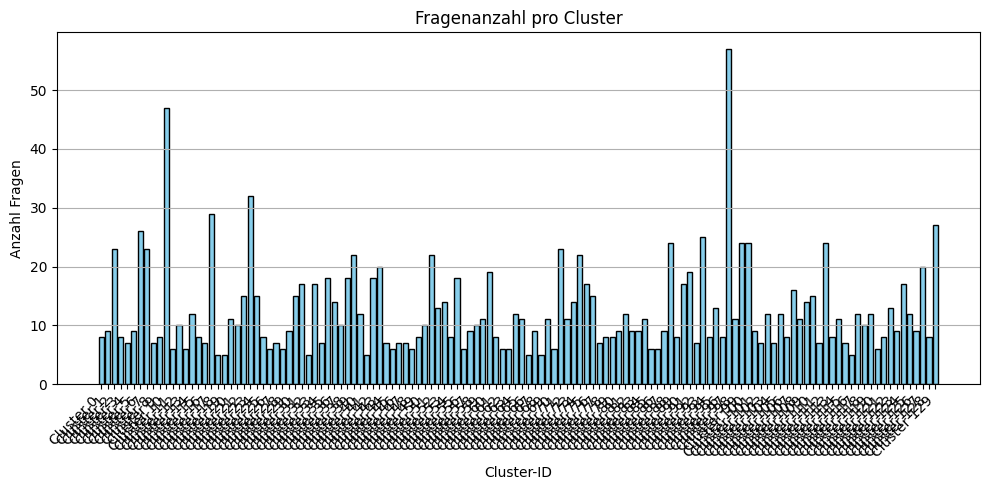

In [8]:
# Zusatz: TF-IDF-Analyse + Fragenanzahl + Wortanzahl (Count) pro Cluster
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import collections
import matplotlib.pyplot as plt
import re

# Stopwörter und Synonyme
stopwords_de = ["aber", "aufgrund", "alle", "als", "also", "am", "an", "ander", "auch", "auf", "aus", "bei", "bin", "bis", "bist", "da", "dadurch", "daher", "darum", "das", "dass", "dein", "deine", "dem", "den", "der", "des", "dessen", "deshalb", "die", "dies", "dieser", "dieses", "doch", "dort", "du", "durch", "ein", "eine", "einem", "einen", "einer", "eines", "er", "es", "euer", "eure", "für", "hatte", "hatten", "hattest", "hattet", "hier", "hinter", "ich", "ihr", "ihre", "im", "in", "ist", "ja", "jede", "jedem", "jeden", "jeder", "jedes", "jener", "jenes", "jetzt", "kann", "kannst", "können", "könnt", "machen", "mein", "meine", "mit", "muß", "mußt", "musst", "müssen", "müßt", "nach", "nachdem", "nein", "nicht", "nun", "oder", "seid", "sein", "seine", "sich", "sie", "sind", "soll", "sollen", "sollst", "sollt", "sonst", "soweit", "sowie", "und", "unser", "unsere", "unter", "vom", "von", "vor", "wann", "warum", "was", "weiter", "weitere", "wegen", "wenn", "wer", "werde", "werden", "werdet", "weshalb", "wie", "wieder", "wir", "wird", "wirst", "wo", "woher", "wohin", "zu", "zum", "zur", "über"]
synonym_map = {
    "vergütung": ["entlohnung", "honorar", "bezahlung"],
    "kündigung": ["beendigung", "auflösung"],
    "vertrag": ["vereinbarung"]
}

def apply_synonyms(texts, mapping):
    updated = []
    for t in texts:
        for target, syns in mapping.items():
            for s in syns:
                t = t.replace(s, target)
        updated.append(t)
    return updated

def tokenize_and_clean(text, stopwords, synonyms):
    for target, syns in synonyms.items():
        for syn in syns:
            text = text.replace(syn, target)
    words = re.findall(r'\b\w+\b', text.lower())
    return [w for w in words if w not in stopwords]

# Fragen + Cluster-Labels extrahieren
all_questions = []
all_labels = []

for cluster_name, cqs in ordered_data.items():
    if cluster_name == "Cluster -1":
        continue
    for cq in cqs:
        all_questions.append(cq["cq"])
        all_labels.append(cluster_name)

# Synonyme anwenden
questions_syn = apply_synonyms(all_questions, synonym_map)

# TF-IDF Analyse
vectorizer = TfidfVectorizer(stop_words=stopwords_de)
X_tfidf = vectorizer.fit_transform(questions_syn)
feature_names = np.array(vectorizer.get_feature_names_out())

# Clusterstruktur vorbereiten
cluster_to_questions = collections.defaultdict(list)
for question, label in zip(questions_syn, all_labels):
    cluster_to_questions[label].append(question)

# TF-IDF Keywords + Häufigkeiten pro Cluster
print("\n🔎 Top TF-IDF Keywords und Wortfrequenz pro Cluster:")
TOP_N = 7

for cluster_id, texts in cluster_to_questions.items():
    matrix = vectorizer.transform(texts).mean(axis=0).A1
    top_indices = matrix.argsort()[-TOP_N:][::-1]
    top_keywords = feature_names[top_indices]
    top_weights = matrix[top_indices]
    
    print(f"\n📁 {cluster_id} (n={len(texts)}):")
    print("Top TF-IDF Keywords:")
    for kw, score in zip(top_keywords, top_weights):
        print(f"  - {kw}: TF-IDF={score:.3f}")
    
    # Häufigkeit (Count) berechnen
    all_tokens = []
    for text in texts:
        all_tokens.extend(tokenize_and_clean(text, stopwords_de, synonym_map))
    counter = collections.Counter(all_tokens)
    print("Top Wörter nach Häufigkeit:")
    for word, count in counter.most_common(TOP_N):
        print(f"  - {word}: {count} mal")

# Plot: Fragenanzahl pro Cluster
plt.figure(figsize=(10, 5))
cluster_sizes = [len(qs) for qs in cluster_to_questions.values()]
plt.bar(cluster_to_questions.keys(), cluster_sizes, color='skyblue', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.title("Fragenanzahl pro Cluster")
plt.xlabel("Cluster-ID")
plt.ylabel("Anzahl Fragen")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

In [9]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Embeddings + Labels aus ordered_data (ohne Cluster -1)
embeddings = []
labels = []
label_map = {}
label_counter = 0

for cluster_name, cqs in ordered_data.items():
    if cluster_name == "Cluster -1":
        continue
    if cluster_name not in label_map:
        label_map[cluster_name] = label_counter
        label_counter += 1
    for cq in cqs:
        embeddings.append(cq["embedding"])
        labels.append(label_map[cluster_name])

embeddings = np.array(embeddings)
labels = np.array(labels)

# Metriken berechnen
sil = silhouette_score(embeddings, labels, metric="cosine")
db = davies_bouldin_score(embeddings, labels)
ch = calinski_harabasz_score(embeddings, labels)

print("\n📊 Clustering-Metriken:")
print(f"Silhouette Score:        {sil:.4f}")
print(f"Davies-Bouldin Score:    {db:.4f}")
print(f"Calinski-Harabasz Score: {ch:.2f}")



📊 Clustering-Metriken:
Silhouette Score:        0.1182
Davies-Bouldin Score:    2.1983
Calinski-Harabasz Score: 14.00
